# 09 · Targeting engine
For every customer: segment, value, recency, campaign history, model probability for the **next** (7th) campaign,
purchase-channel evidence, priority tier, recommended action and the reasons (exact log-odds contributions of the
logistic model).

**How the priority framework was chosen (evaluated, not assumed):** five scoring methods were back-tested on the
pilot with actual outcomes — model probability, prior-acceptance rule, RFM, historical value and a rank blend of
probability and value. No arbitrary weights (e.g. 30/40/30) are used.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4g}")
from src import pipeline as P
from src.config import *

[19:43:08] targeting engine


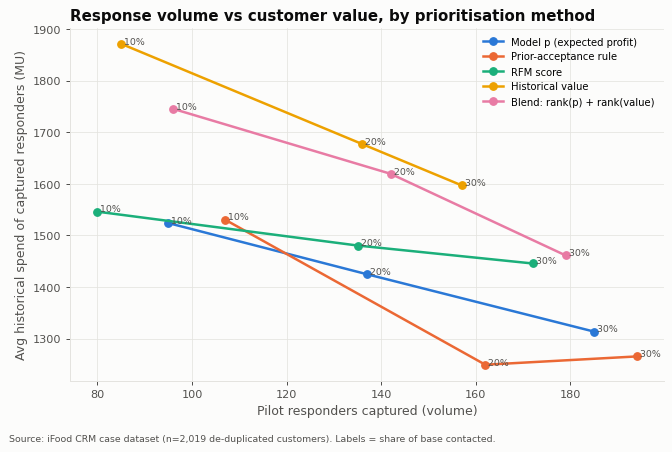

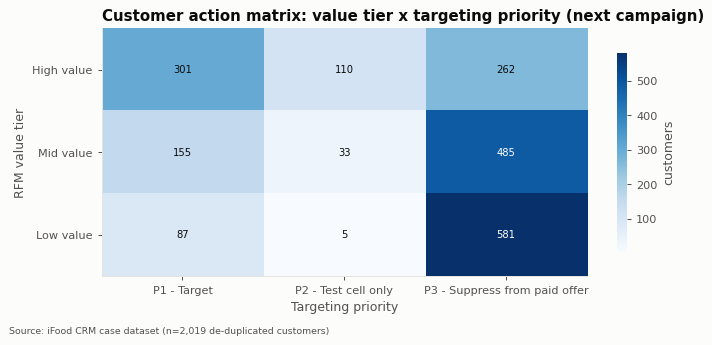

,method,contact_share,contacts,responses,response_rate,profit_mu,avg_hist_spend_contacted,avg_hist_spend_responders
0,Model p (expected profit),0.1,202,95,0.4703,439,"1,400","1,524"
1,Model p (expected profit),0.2,404,137,0.3391,295,"1,257","1,425"
2,Model p (expected profit),0.3,606,185,0.3053,217,"1,151","1,314"
3,Prior-acceptance rule,0.1,202,107,0.5297,571,"1,497","1,530"
4,Prior-acceptance rule,0.2,404,162,0.401,570,"1,123","1,249"
5,Prior-acceptance rule,0.3,606,194,0.3201,316,"1,120","1,265"
6,RFM score,0.1,202,80,0.396,274,"1,404","1,546"
7,RFM score,0.2,404,135,0.3342,273,"1,311","1,480"
8,RFM score,0.3,606,172,0.2838,74,"1,271","1,446"
9,Historical value,0.1,202,85,0.4208,329,"1,825","1,871"


In [2]:
ctx = P.prepare('stage_targeting')
ctx = P.stage_targeting(ctx)
ctx['priority_methods']

> **Finding:** At a 10–20 % contact budget the prior-acceptance rule (ties ordered by the model) earns the most back-tested profit (571 / 570 MU) vs the pure model ranking (439 / 295 MU), RFM (274 / 273) and historical value (329 / 284). The probability/value blend captures responders with 14–30 % higher historical spend than the rule (1,745 vs 1,530 MU at 10 %; 1,619 vs 1,249 MU at 20 %) at a profit cost of 121–220 MU.
>
> **Business implication:** The evidence favours a rule-first, model-second framework; value is a trade-off dial, not a free lunch.
>
> **Recommended action:** Tiers: **P1** = accepted ≥1 campaign (ordered by model p); **P2** = never accepted but top-10 % model p (test cell only); **P3** = suppress.
>
> **Evidence:** Priority-method back-test and tier back-test below.
>
> **Assumption:** The next offer has the pilot's economics and audience.
>
> **Limitation:** Back-test on a single campaign; different offers attract different customers (notebook 06).

In [3]:
ctx['priority_backtest']

,tier,customers,responders,response_rate,ci_low,ci_high,profit_mu,above_break_even
0,P1 - Target,417,168,0.4029,0.3569,0.4506,597,True
1,P2 - Test cell only,161,24,0.1491,0.1023,0.2122,-219,False
2,P3 - Suppress from paid offer,1441,102,0.07078,0.05865,0.0852,"-3,201",False


In [4]:
ctx['action_summary']

,priority,action,customers,avg_p,avg_spend,expected_profit_total
0,P1 - Target,Include in next offer (responsive; lower basket value),242,0.2713,439.2,-3.813
1,P1 - Target,Include in next offer - priority (responsive + high value),301,0.4781,"1,463",679.9
2,P2 - Test cell only,Randomised test cell with holdout (expected below break-even),148,0.1652,"1,181",-175
3,P3 - Suppress from paid offer,No paid offer; high value but never accepted - review offer relevance / non-paid touch,262,0.0648,"1,039",-599.3
4,P3 - Suppress from paid offer,"Suppress from paid offer (no response history, low predicted response)",1066,0.04036,215.1,"-2,725"


In [5]:
ctx['action_matrix']

priority,P1 - Target,P2 - Test cell only,P3 - Suppress from paid offer,All
value_tier,,,,
High value,301,110,262,673
Low value,87,5,581,673
Mid value,155,33,485,673
All,543,148,1328,2019


In [6]:
e = ctx['engine']
e[['ID','priority','action','rfm_segment','value_tier','total_spend','Recency','n_accepted_all6','p_next_campaign','expected_profit_mu','drivers_up_logodds','channel_evidence']].head(10)

,ID,priority,action,rfm_segment,value_tier,total_spend,Recency,n_accepted_all6,p_next_campaign,expected_profit_mu,drivers_up_logodds,channel_evidence
0,3138,P1 - Target,Include in next offer - priority (responsive + high value),High-value (lapsing),High value,1676,84,5,0.9794,7.774,campaign acceptances so far (+4.96); 2-yr spend (+0.58); income (+0.33),"Mixed: pilot response 24.3% (95% CI 21.2%-27.7%, n=679)"
1,3725,P1 - Target,Include in next offer (responsive; lower basket value),Mid-value (recent),Mid value,1688,1,5,0.9779,7.757,campaign acceptances so far (+4.96); 2-yr spend (+0.58); days since last purchase (+0.30),"Store: pilot response 6.7% (95% CI 5.3%-8.3%, n=1065)"
2,3174,P1 - Target,Include in next offer - priority (responsive + high value),High-value (cooling),High value,1957,61,5,0.9721,7.693,campaign acceptances so far (+4.96); 2-yr spend (+0.73); catalog purchase share (+0.37),"Catalog: pilot response 31.6% (95% CI 19.1%-47.5%, n=38)"
3,3009,P1 - Target,Include in next offer (responsive; lower basket value),Mid-value (recent),Mid value,1766,8,4,0.9697,7.667,campaign acceptances so far (+3.94); 2-yr spend (+0.63); category breadth (+0.27),"Mixed: pilot response 24.3% (95% CI 21.2%-27.7%, n=679)"
4,5758,P1 - Target,Include in next offer - priority (responsive + high value),Core high-value (recent),High value,1189,23,5,0.9659,7.625,campaign acceptances so far (+4.96); category breadth (+0.37); 2-yr spend (+0.31),"Mixed: pilot response 24.3% (95% CI 21.2%-27.7%, n=679)"
5,8545,P1 - Target,Include in next offer - priority (responsive + high value),Core high-value (recent),High value,1789,6,5,0.9642,7.606,campaign acceptances so far (+4.96); 2-yr spend (+0.64); income (+0.28),"Store: pilot response 6.7% (95% CI 5.3%-8.3%, n=1065)"
6,9058,P1 - Target,Include in next offer - priority (responsive + high value),High-value (cooling),High value,1867,65,4,0.9578,7.536,campaign acceptances so far (+3.94); 2-yr spend (+0.68); catalog purchase share (+0.36),"Catalog: pilot response 31.6% (95% CI 19.1%-47.5%, n=38)"
7,477,P1 - Target,Include in next offer - priority (responsive + high value),Core high-value (recent),High value,2157,31,5,0.9561,7.517,campaign acceptances so far (+4.96); 2-yr spend (+0.84); income (+0.26),"Mixed: pilot response 24.3% (95% CI 21.2%-27.7%, n=679)"
8,10089,P1 - Target,Include in next offer - priority (responsive + high value),Core high-value (recent),High value,1112,5,5,0.9548,7.503,campaign acceptances so far (+4.96); income (+0.42); days since last purchase (+0.28),"Mixed: pilot response 24.3% (95% CI 21.2%-27.7%, n=679)"
9,5067,P1 - Target,Include in next offer - priority (responsive + high value),Core high-value (recent),High value,1378,11,4,0.9365,7.301,campaign acceptances so far (+3.94); 2-yr spend (+0.42); days since last purchase (+0.24),"Store: pilot response 6.7% (95% CI 5.3%-8.3%, n=1065)"


## Case studies (real customers, selected by explicit rules)

In [7]:
print(open(TAB/'case_studies.md').read())

### Case 1 - High-value customer — customer ID 1763
*Selected by rule:* highest 2-yr spend among P1 customers.

1. **Profile:** income 87,679, age 26, tenure 11.1 months.
2. **Behaviour:** 28 purchases (web 25%, catalog 39%, store 36%); last purchase 62 days ago; 4 web visits last month.
3. **Segment:** High-value (cooling) (RFM 2-5-5); cluster 'High-value, full-price'.
4. **Campaign history (C1..C6):** 101011 -> accepted 4/6.
5. **Value:** 2-yr spend 2,524 MU (percentile 100); AOV 90.1 MU.
6. **Response behaviour:** pilot (C6) accepted.
7. **Prediction:** model p(next campaign) = 0.92 vs break-even 0.273; drivers up: campaign acceptances so far (+3.94); 2-yr spend (+1.03); income (+0.30); drivers down: accepted most recent campaign (-0.57); gold-product share (-0.23).
8. **Channel evidence:** Mixed: pilot response 24.3% (95% CI 21.2%-27.7%, n=679). (Purchase channel, not campaign delivery channel.)
9. **Recommendation:** P1 - Target -> Include in next offer - priority (responsive + hi

**Channel/campaign recommendation.** The data contain no customer-level history of campaign *delivery* channels, so the engine
does not claim a 'preferred channel'. It reports the purchase-channel mix and the pilot response of customers with the same
dominant purchase channel, with confidence intervals. The campaign-*type* recommendation (which offer for whom) comes from the
randomised Hillstrom experiment in notebook 10.